In [3]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table, vstack, Column, join
from scipy.stats import binned_statistic

In [2]:
embedding_path = 'desi_bgs_embeddings_020226_subsampled.csv'

# DR1 fastspec properties (must be run on NERSC)
fastspec_fit_path = '/global/cfs/cdirs/desi/public/dr1/vac/dr1/fastspecfit/iron/v2.1/catalogs/fastspec-iron-main-dark.fits'
gal_embedding = Table.read(embedding_path)
fastspec_catalog = Table.read(fastspec_fit_path)

In [4]:
fastspec_catalog.keep_columns(['TARGETID', 'Z', 'AGE', 'VDISP', 'ZZSUN', 'LOGMSTAR', 'SFR', 
                               'FLUX_SYNTH_G', 'FLUX_SYNTH_R', 'FLUX_SYNTH_Z', 
                               'ABSMAG10_DECAM_G', 'ABSMAG10_DECAM_R', 'ABSMAG10_DECAM_Z'])

Selecting and adding relevant columns to the galaxy catalog

Description of fastspecfit columns: https://fastspecfit.readthedocs.io/en/latest/fastspec.html#id23

Now combining. For BGS especially, not all galaxies with embeddings will have fastspec properties.

In [5]:
print(len(gal_embedding))
joined_table = join(gal_embedding, fastspec_catalog, keys='TARGETID', join_type='inner')
print(len(joined_table))

9437
226


In [6]:
# round all values in joined table to 4 decimal places
joined_table.round(4)

In [7]:
# adding column for color
joined_table['G-R'] = -2.5 * np.log10(joined_table['FLUX_SYNTH_G'] / joined_table['FLUX_SYNTH_R']) + (joined_table['ABSMAG10_DECAM_G'] - joined_table['ABSMAG10_DECAM_R'])

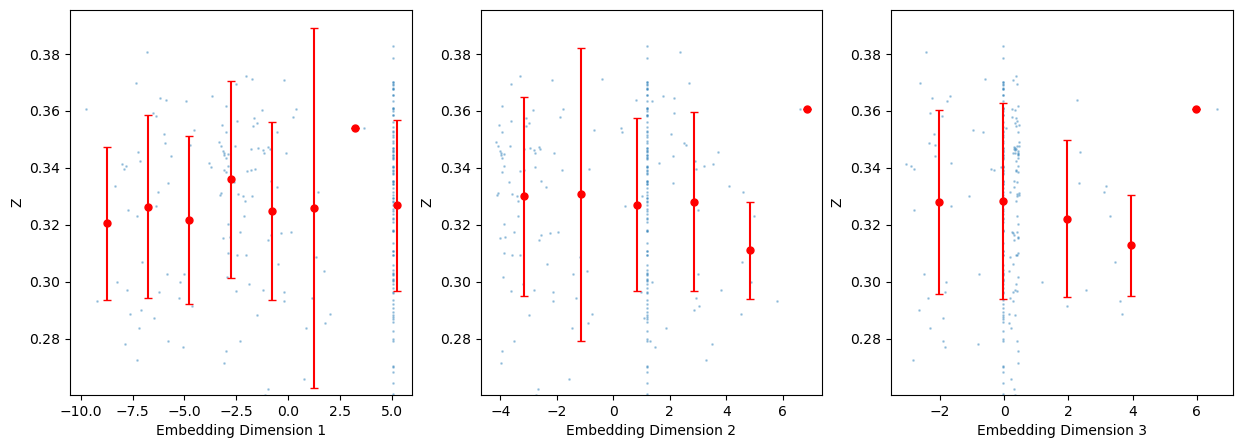

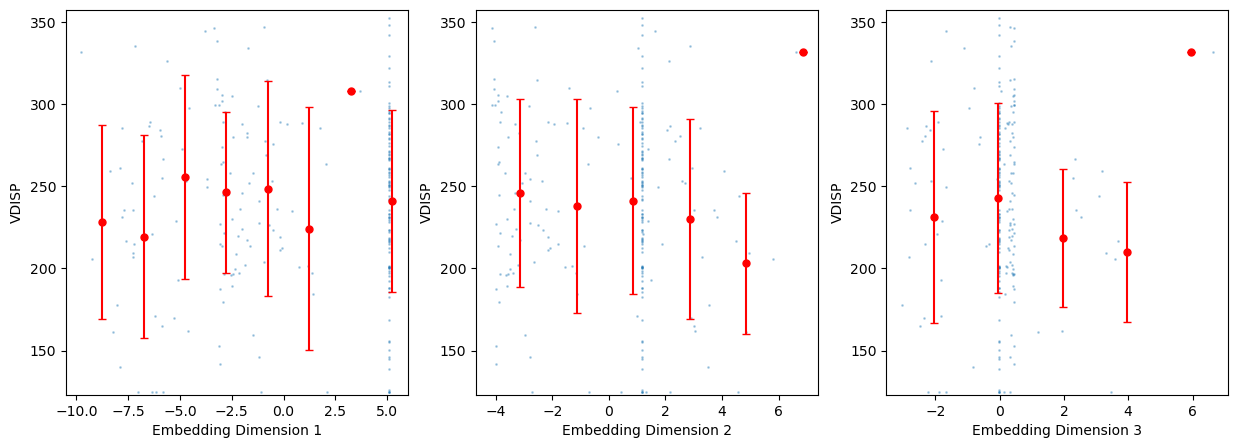

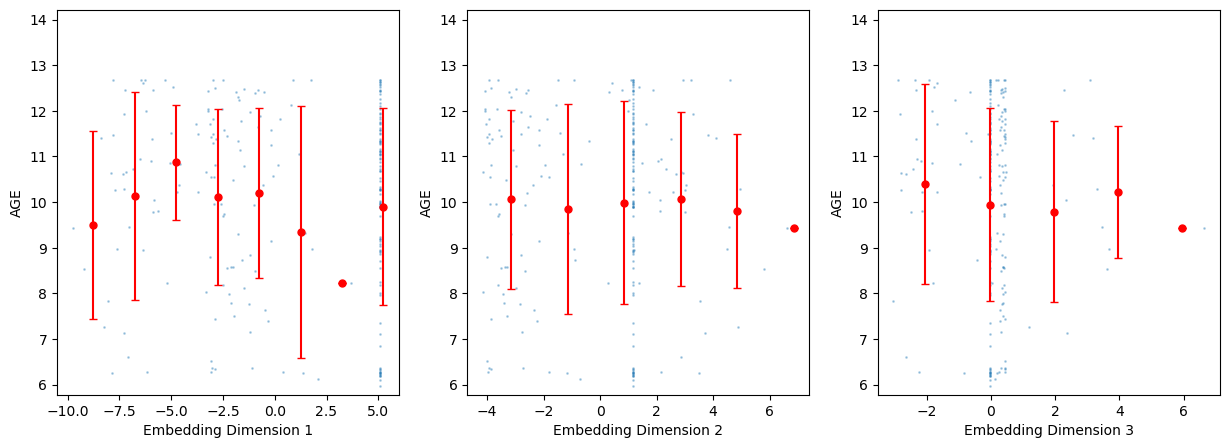

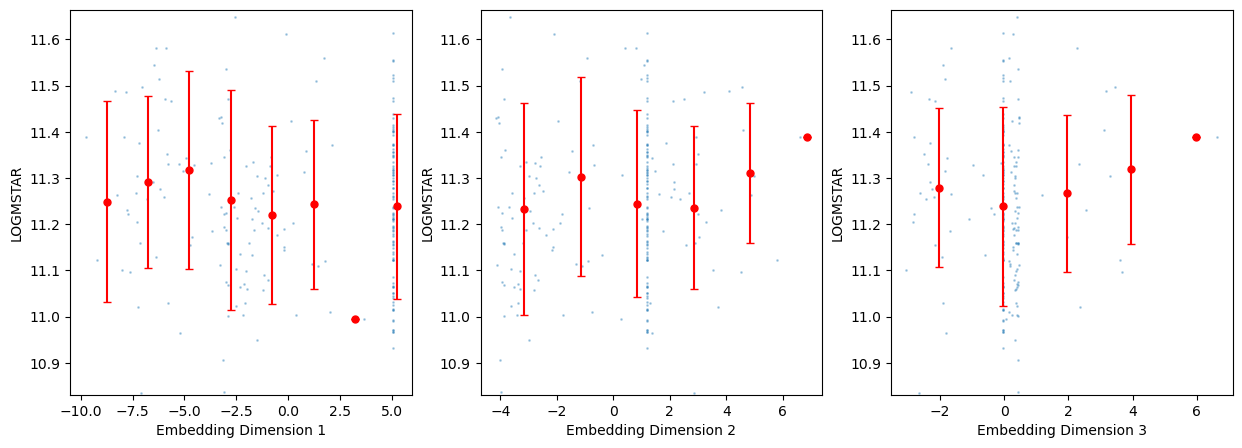

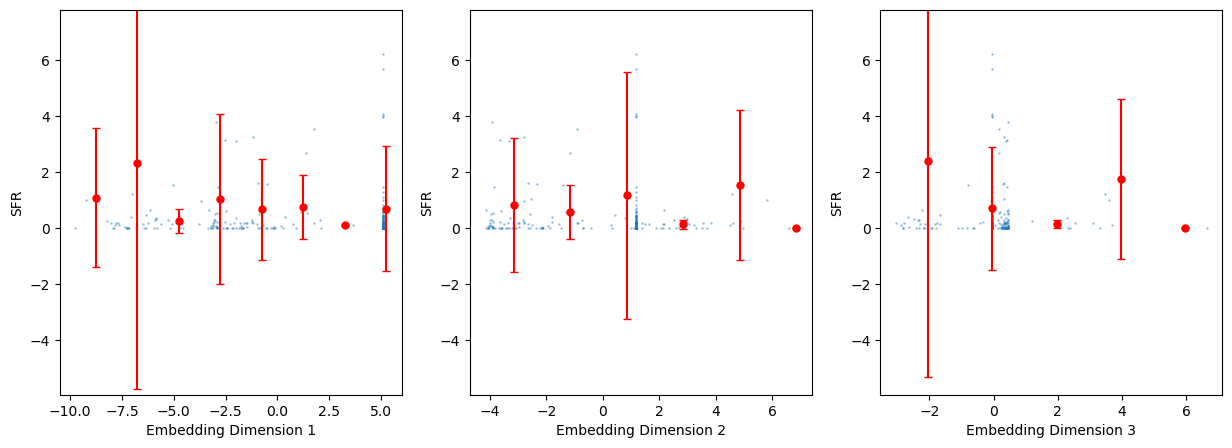

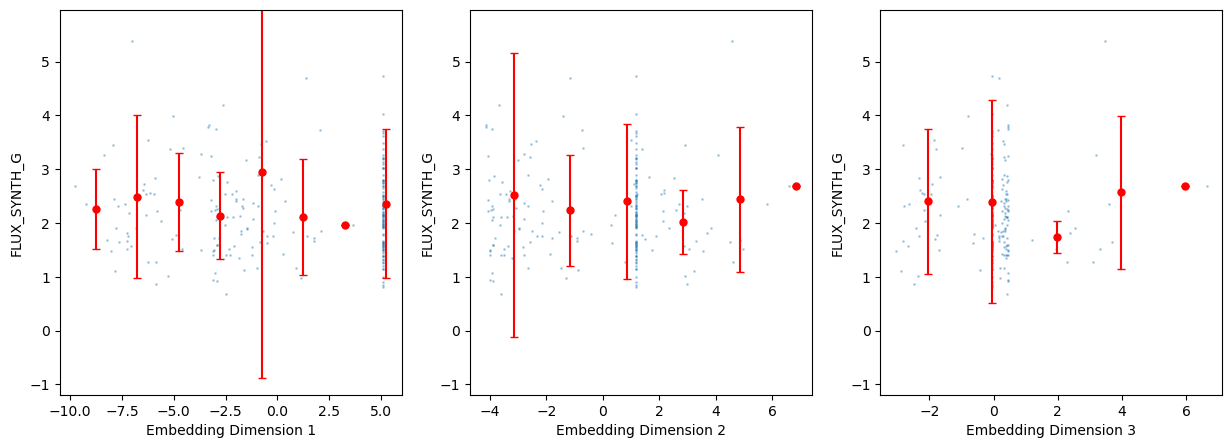

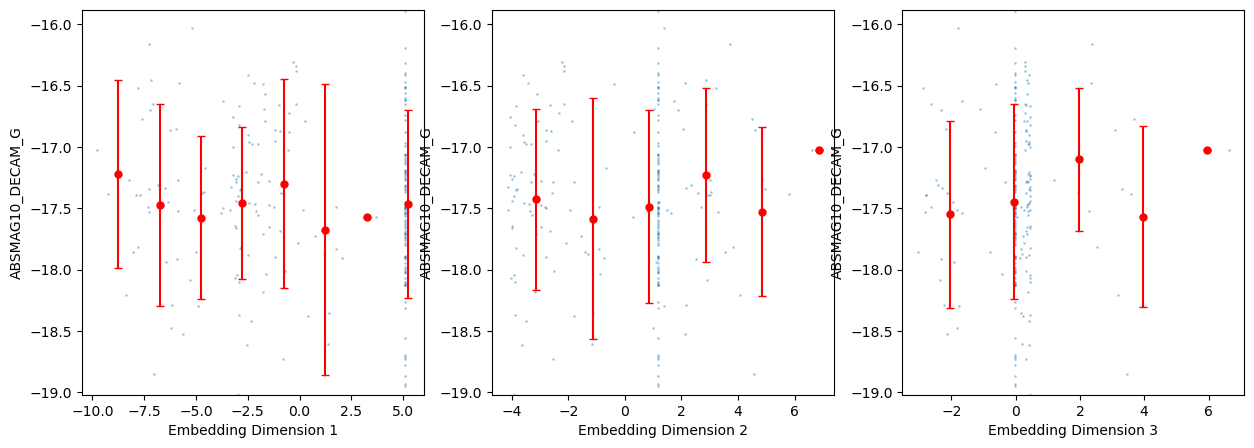

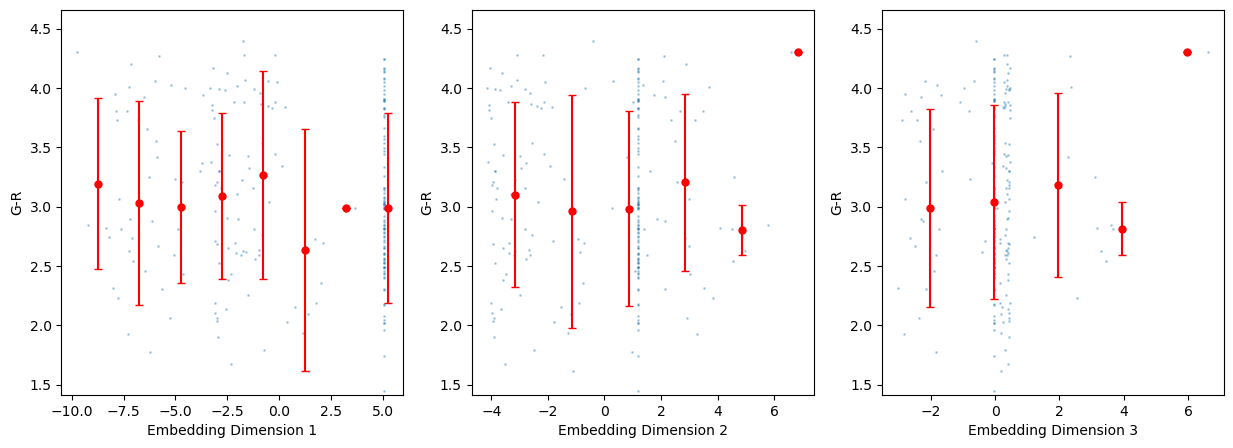

In [ ]:
s = 1
alpha=.3
bin_width = 2 # usually needs to be adjusted for BGS (2) / LRG (5)

for column in ['Z', 'VDISP', 'AGE', 'LOGMSTAR', 'SFR', 'FLUX_SYNTH_G', 'ABSMAG10_DECAM_G', 'G-R']:
    
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15,5))
    y = np.array(joined_table[column])
    
    # Embedding 1 vs column
    x1 = np.array(joined_table['embedding_1'])
    mask1 = np.isfinite(x1) & np.isfinite(y)
    scatter = ax1.scatter(x1, y, s=s, alpha=alpha)
    bins1 = np.arange(np.nanmin(x1), np.nanmax(x1) + bin_width, bin_width)
    bin_means1, bin_edges1, _ = binned_statistic(x1[mask1], y[mask1], statistic='mean', bins=bins1)
    bin_stds1, _, _ = binned_statistic(x1[mask1], y[mask1], statistic='std', bins=bins1)
    bin_centers1 = (bin_edges1[:-1] + bin_edges1[1:]) / 2
    ax1.errorbar(bin_centers1, bin_means1, yerr=bin_stds1, fmt='ro', markersize=5, capsize=3)
    ax1.set_xlabel('Embedding Dimension 1')
    ax1.set_ylabel(column)
    
    # Embedding 2 vs column
    x2 = np.array(joined_table['embedding_2'])
    mask2 = np.isfinite(x2) & np.isfinite(y)
    scatter = ax2.scatter(x2, y, s=s, alpha=alpha)
    bins2 = np.arange(np.nanmin(x2), np.nanmax(x2) + bin_width, bin_width)
    bin_means2, bin_edges2, _ = binned_statistic(x2[mask2], y[mask2], statistic='mean', bins=bins2)
    bin_stds2, _, _ = binned_statistic(x2[mask2], y[mask2], statistic='std', bins=bins2)
    bin_centers2 = (bin_edges2[:-1] + bin_edges2[1:]) / 2
    ax2.errorbar(bin_centers2, bin_means2, yerr=bin_stds2, fmt='ro', markersize=5, capsize=3)
    ax2.set_xlabel('Embedding Dimension 2')
    ax2.set_ylabel(column)
    
    # Embedding 3 vs column
    x3 = np.array(joined_table['embedding_3'])
    mask3 = np.isfinite(x3) & np.isfinite(y)
    scatter = ax3.scatter(x3, y, s=s, alpha=alpha)
    bins3 = np.arange(np.nanmin(x3), np.nanmax(x3) + bin_width, bin_width)
    bin_means3, bin_edges3, _ = binned_statistic(x3[mask3], y[mask3], statistic='mean', bins=bins3)
    bin_stds3, _, _ = binned_statistic(x3[mask3], y[mask3], statistic='std', bins=bins3)
    bin_centers3 = (bin_edges3[:-1] + bin_edges3[1:]) / 2
    ax3.errorbar(bin_centers3, bin_means3, yerr=bin_stds3, fmt='ro', markersize=5, capsize=3)
    ax3.set_xlabel('Embedding Dimension 3')
    ax3.set_ylabel(column)
    
    # Limit y-axis to 2 sigma of values
    mean = np.nanmean(joined_table[column])
    std = np.nanstd(joined_table[column])
    y_min = mean - 2 * std
    y_max = mean + 2 * std
    
    for ax in [ax1, ax2, ax3]:
        ax.set_ylim(y_min, y_max)